# Pest Benchmark: Vanilla BO vs Casmopolitan
This notebook benchmarks `BOTORCH_MODULAR` against `CASMOPOLITAN` on the PestControl categorical search space.

The optimization target is the PestControl objective, so lower is better.
- each variation is run `n_repeats` times
- the final comparison plot shows the mean best objective with standard deviation shading


In [1]:
# Import necessary libraries
import warnings, os, sys, time
os.environ['PYTHONWARNINGS'] = 'ignore'
warnings.filterwarnings('ignore')
warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=UserWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from optimpv import *
    from optimpv.optimizers.axBOtorch.axUtils import *
    from optimpv.optimizers.axBOtorch.axBOtorchOptimizer import axBOtorchOptimizer
    from optimpv.tests.Pest.PestAgent import PestAgent
except Exception:
    sys.path.append('../..')
    from optimpv import *
    from optimpv.optimizers.axBOtorch.axUtils import *
    from optimpv.optimizers.axBOtorch.axBOtorchOptimizer import axBOtorchOptimizer
    from optimpv.tests.Pest.PestAgent import PestAgent

plt.style.use('default')


## Benchmark Setup


In [2]:
# Main notebook setup
n_init = 20
total_evaluations = 80
batch_size = 1

n_repeats = 2
seed_base = 3
pest_random_seed = 0

variations = [
    {'label': 'Vanilla BO', 'method': 'vanilla_bo'},
    {'label': 'Casmopolitan', 'method': 'casmopolitan'},
]

print(f'Total evaluations per run: {total_evaluations}')
print(f'Repeats per variation: {n_repeats}')
print(f'Seed base: {seed_base}')
print('Variations:')
for variation in variations:
    print('  -', variation['label'])


Total evaluations per run: 80
Repeats per variation: 2
Seed base: 3
Variations:
  - Vanilla BO
  - Casmopolitan


In [3]:
# Define the categorical Pest parameters
params = []
for i in range(25):
    params.append(
        FitParam(
            name=f'pest_{i}',
            value='0',
            values=['0', '1', '2', '3', '4'],
            log_scale=False,
            rescale=False,
            value_type='str',
            type='choice',
            display_name=f'pest_{i}',
            unit='',
        )
    )

num_free_params = len([p for p in params if p.type != 'fixed'])
print(f'Number of free parameters: {num_free_params}')

agent = PestAgent(
    params=params,
    random_seed=pest_random_seed,
    metric='obj',
    loss='linear',
    minimize=True,
    name='pest',
)


Number of free parameters: 25


In [4]:
# Optimizer builders and history extraction

def build_optimizer(variation, seed=0):

    if variation['method'] == 'vanilla_bo':
        model_kwargs_list = get_VMLC_default_model_kwargs_list(
            num_free_params=num_free_params,
            has_categorical=True,
        )
        model_kwargs_list[0] = {'seed': seed}
        models = ['SOBOL', 'BOTORCH_MODULAR']
    elif variation['method'] == 'casmopolitan':
        model_kwargs_list = [
            {'seed': seed},
            {
                'acq': 'ei',
                'n_training_steps': 150,
                'guided_restart': False,
            },
        ]
        models = ['SOBOL', 'CASMOPOLITAN']
    else:
        raise ValueError(f"Unknown method: {variation['method']}")

    return axBOtorchOptimizer(
        params=params,
        agents=agent,
        models=models,
        n_batches=[1, total_evaluations - n_init],
        batch_size=[n_init, batch_size],
        model_kwargs_list=model_kwargs_list,
        max_parallelism=1,
        verbose_logging=False,
        name=f"pest_{variation['method']}",
    )


def extract_history(optimizer):
    df = optimizer.ax_client._experiment.lookup_data().df.copy()
    metric_name = optimizer.all_metrics[0]
    hist = (
        df[df['metric_name'] == metric_name]
        .sort_values('trial_index')
        .loc[:, ['trial_index', 'mean']]
        .reset_index(drop=True)
    )
    hist['evaluation'] = np.arange(1, len(hist) + 1)
    hist['best_obj_val'] = np.minimum.accumulate(hist['mean'].to_numpy())
    return hist, metric_name


def run_variation(variation, seed=0):
    optimizer = build_optimizer(variation=variation, seed=seed)
    start_time = time.time()
    optimizer.optimize()
    runtime = time.time() - start_time
    history, metric_name = extract_history(optimizer)
    return {
        'label': variation['label'],
        'history': history,
        'metric_name': metric_name,
        'runtime': runtime,
        'best_value': float(history['best_obj_val'].iloc[-1]),
    }


def combine_runs(label, runs_for_variation):
    history_mean = pd.DataFrame({'evaluation': runs_for_variation[0]['history']['evaluation']})

    run_cols = []
    for idx, run in enumerate(runs_for_variation):
        col = f'run_{idx}'
        history_mean[col] = run['history']['best_obj_val'].to_numpy()
        run_cols.append(col)

    history_mean['mean_best_obj_val'] = history_mean[run_cols].mean(axis=1)
    history_mean['standard_deviation'] = history_mean[run_cols].std(axis=1)

    final_best_values = [run['best_value'] for run in runs_for_variation]
    runtimes = [run['runtime'] for run in runs_for_variation]

    return {
        'label': label,
        'runs': runs_for_variation,
        'history_mean': history_mean,
        'mean_runtime': float(np.mean(runtimes)),
        'mean_best_obj_val': float(np.mean(final_best_values)),
        'standard_deviation': float(np.std(final_best_values)),
    }


## Run Repeated Benchmark


In [5]:
all_runs = []
for variation in variations:
    variation_runs = []
    for repeat_idx in range(n_repeats):
        seed = seed_base + repeat_idx
        print(f"Running {variation['label']} | repeat {repeat_idx + 1}/{n_repeats} | seed={seed}")
        variation_runs.append(run_variation(variation, seed=seed))
    all_runs.append({'label': variation['label'], 'runs': variation_runs})

combined_runs = []
for group in all_runs:
    combined_runs.append(combine_runs(group['label'], group['runs']))


Running Vanilla BO | repeat 1/2 | seed=3
Running Vanilla BO | repeat 2/2 | seed=4
Running Casmopolitan | repeat 1/2 | seed=3
Running Casmopolitan | repeat 2/2 | seed=4


In [6]:
summary_df = pd.DataFrame(
    {
        'variation': run['label'],
        'mean_runtime': run['mean_runtime'],
        'mean_best_obj_val': run['mean_best_obj_val'],
        'standard_deviation': run['standard_deviation'],
    }
    for run in combined_runs
).sort_values('mean_best_obj_val', ascending=True).reset_index(drop=True)

summary_df


,variation,mean_runtime,mean_best_obj_val,standard_deviation
0,Vanilla BO,116.579829,13.239800,0.454199
1,Casmopolitan,214.314739,13.973199,0.181600


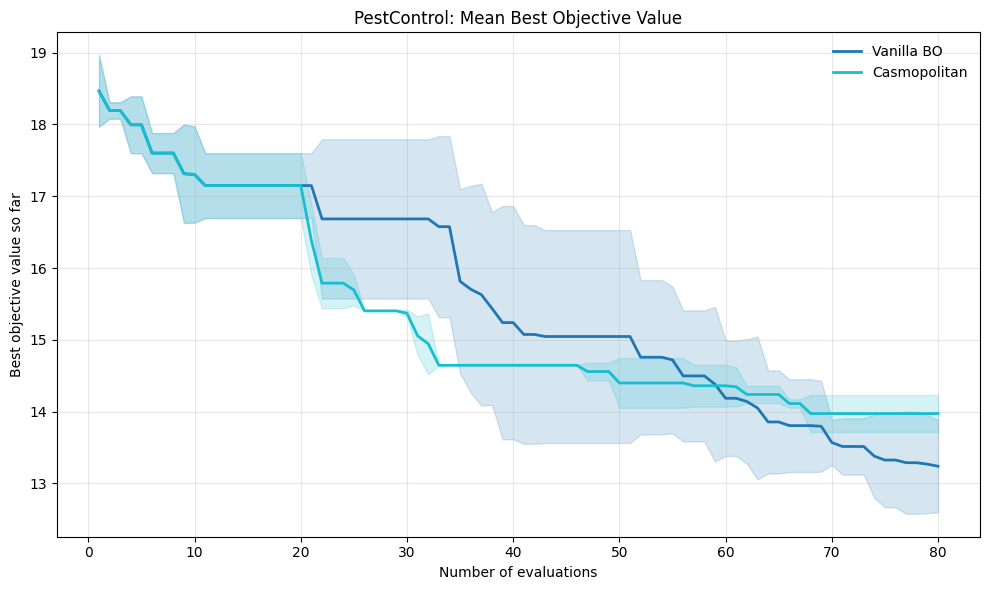

In [7]:
colors = plt.get_cmap('tab10')(np.linspace(0, 1, len(combined_runs)))

fig, ax = plt.subplots(1, 1, figsize=(10, 6))

for color, run in zip(colors, combined_runs):
    hist = run['history_mean']
    ax.plot(
        hist['evaluation'],
        hist['mean_best_obj_val'],
        color=color,
        lw=2.0,
        label=run['label'],
    )
    ax.fill_between(
        hist['evaluation'],
        hist['mean_best_obj_val'] - hist['standard_deviation'],
        hist['mean_best_obj_val'] + hist['standard_deviation'],
        color=color,
        alpha=0.18,
    )

ax.set_title('PestControl: Mean Best Objective Value')
ax.set_xlabel('Number of evaluations')
ax.set_ylabel('Best objective value so far')
ax.grid(True, alpha=0.3)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()
